In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

In [3]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [4]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [5]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [6]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0.5e3            # V
line['frf'] = 1 / tw4d.t_rev0 # h=1

env['dp'] = 0
line.append(
    env.new('tdelay', xt.TimeDelay, shift_zeta=-eta * line_length * env.ref['dp']))

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [7]:
env['dp'] = 0 #-2.5e-3
tw_carbon = line.twiss6d()
tw_helium = line.twiss6d(mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

In [8]:
alpha_c = tw_carbon.momentum_compaction_factor
eta_c = tw_carbon.slip_factor
chi_he = tw_helium.particle_on_co.chi[0]
delta_diff_expected = alpha_c / eta_c * (chi_he - 1)

In [9]:
float(delta_diff_expected), float(tw_helium.delta[0] - tw_carbon.delta[0])

(0.00025578879022525937, 0.0002563143177092275)

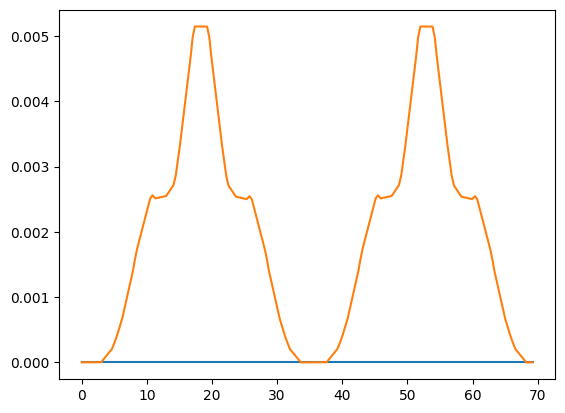

In [10]:
plt.plot(tw_carbon.s, tw_carbon.x)
plt.plot(tw_carbon.s, tw_helium.x)

In [11]:
tw_carbon.qx

np.float64(1.6400058897595002)

In [12]:
tw_helium.qx

np.float64(1.640002026555341)

In [13]:
# Calibrate the chromaticity knob with the extraction sextupoles at full strength.
env['kse'] = 3.
tw_chrom = line.twiss4d()

opt = line.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_x',
    knob_value_start=tw_chrom.dqx,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=1., dqy=tw_chrom.dqy, tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 1.01                              
Matching: model call n. 6 penalty = 4.7968e-05              
Optimize - end penalty:  4.79676e-05                            
Target status:               alty = 4.7968e-05              
id state tag tol_met       residue   current_val    target_val description                                 
0  ON    dqx    True  -4.79674e-05      0.999952             1 'dqx', val=1, tol=0.0001, weight=1          
1  ON    dqy    True  -1.02838e-07         -0.01   -0.00999993 'dqy', val=-0.00999993, tol=0.0001, weig ...
Generated knob:  chrom_x                       


In [14]:
chrom_list = np.linspace(-2, 2, 11)
qx_carbon = []
qx_helium = []

for cc in chrom_list:
    env['chrom_x'] = cc
    tw_carbon = line.twiss6d()
    tw_helium = line.twiss6d(
        mass_ratio=mass_ratio_he_ca,
        charge_ratio=charge_ratio_he_ca)
    qx_carbon.append(tw_carbon.qx)
    qx_helium.append(tw_helium.qx)


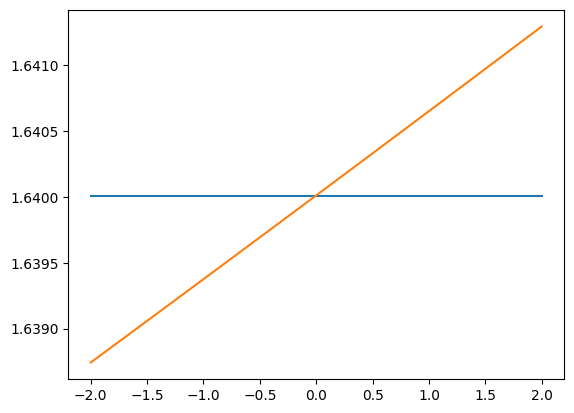

In [15]:
plt.plot(chrom_list, qx_carbon)
plt.plot(chrom_list, qx_helium)